In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

In [5]:
# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [7]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [ ]:
grouped_df = ...

In [10]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [11]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

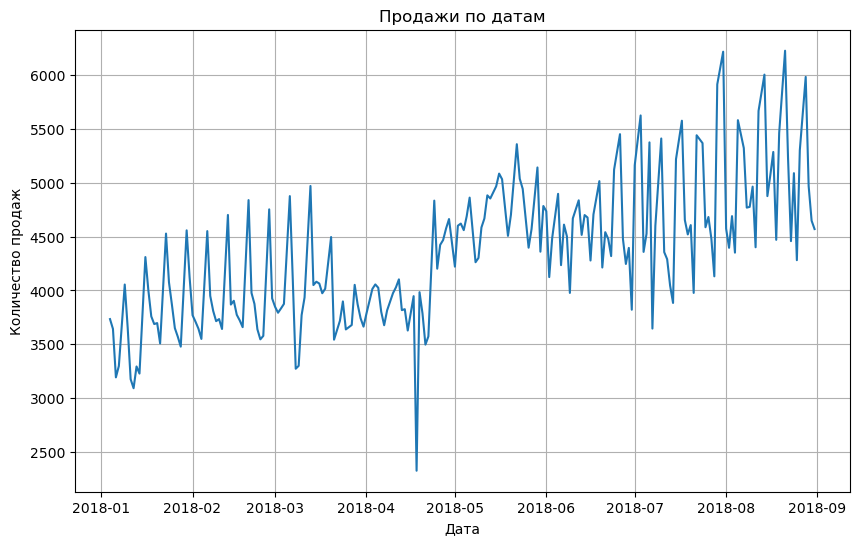

In [13]:
plt.figure(figsize=(10,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

**На графике отображена динамика количества продаж по датам.
Видно, что продажи имеют неравномерный характер: наблюдаются как периоды роста, так и спады.
В некоторые даты присутствуют резкие пики — это может свидетельствовать о выбросах или аномально высоких продажах.
Общая тенденция может указывать на сезонность или влияние внешних факторов.**

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [14]:
df[df['Количество'] == df['Количество'].max()]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [16]:
# фильтр
filtered = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6,7,8])) &
    (df['Дата'].dt.weekday == 2)  # среда = 2
]

# группировка
top_product = (
    filtered.groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

top_product

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [45]:
weather = pd.read_csv(
    'weather.csv',
    sep=';',
    encoding='latin1',
    skiprows=6,
    on_bad_lines='skip'
)

In [46]:
weather.head()

,ÐÐµÑÑÐ½Ð¾Ðµ Ð²ÑÐµÐ¼Ñ Ð² ÐÑÑÐ°Ð½Ðµ,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2023 23:00,12.9,724.5,755.1,-0.4,77,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ ÑÐ³Ð°",3,NaN,NaN,"90 Ð¸Ð»Ð¸ Ð±Ð¾Ð»ÐµÐµ, Ð½Ð¾ Ð½Ðµ 100%",...,"ÐÐµÑÐ¸ÑÑÑÑ , Ð¿ÐµÑÐ¸ÑÑÐ¾-ÐºÑÑÐµÐ²ÑÑ...",NaN,9.0,4.0,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2023 20:00,14.3,724.9,755.4,0.3,59,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ ÑÐ³Ð°",4,NaN,NaN,"90 Ð¸Ð»Ð¸ Ð±Ð¾Ð»ÐµÐµ, Ð½Ð¾ Ð½Ðµ 100%",...,"ÐÐµÑÐ¸ÑÑÑÑ , Ð¿ÐµÑÐ¸ÑÑÐ¾-ÐºÑÑÐµÐ²ÑÑ...",NaN,6.3,4.0,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2023 17:00,17.1,724.6,754.7,0.6,45,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ Ð·Ð°Ð¿Ð°Ð´Ð°",3,NaN,NaN,"90 Ð¸Ð»Ð¸ Ð±Ð¾Ð»ÐµÐµ, Ð½Ð¾ Ð½Ðµ 100%",...,"ÐÐµÑÐ¸ÑÑÑÐµ Ð½Ð¸ÑÐµÐ²Ð¸Ð´Ð½ÑÐµ, Ð¸Ð½Ð¾Ð...",10.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2023 14:00,17.1,724.0,754.1,1.5,48,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ Ð·Ð°Ð¿Ð°Ð´Ð°",3,NaN,NaN,100%.,...,"ÐÐµÑÐ¸ÑÑÑÐµ Ð½Ð¸ÑÐµÐ²Ð¸Ð´Ð½ÑÐµ, Ð¸Ð½Ð¾Ð...",10.0,5.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2023 11:00,13.5,722.5,752.9,0.4,72,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ ÑÐ³Ð¾-Ð²Ð¾ÑÑÐ¾ÐºÐ°",3,NaN,NaN,"90 Ð¸Ð»Ð¸ Ð±Ð¾Ð»ÐµÐµ, Ð½Ð¾ Ð½Ðµ 100%",...,"ÐÐµÑÐ¸ÑÑÑÑ , Ð¿ÐµÑÐ¸ÑÑÐ¾-ÐºÑÑÐµÐ²ÑÑ...",4.0,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
weather.columns

Index(['ÐÐµÑÑÐ½Ð¾Ðµ Ð²ÑÐµÐ¼Ñ Ð² ÐÑÑÐ°Ð½Ðµ', 'T', 'Po', 'P', 'Pa', 'U',
       'DD', 'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl',
       'Nh', 'H', 'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')

In [48]:
with open('weather.csv', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()

data_lines = [line for line in lines if not line.startswith('#')]

In [49]:
from io import StringIO

weather = pd.read_csv(
    StringIO(''.join(data_lines)),
    sep=';'
)

In [50]:
weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2023 23:00,12.9,724.5,755.1,-0.4,77,"Ветер, дующий с юга",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,9.0,4.0,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2023 20:00,14.3,724.9,755.4,0.3,59,"Ветер, дующий с юга",4,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,6.3,4.0,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2023 17:00,17.1,724.6,754.7,0.6,45,"Ветер, дующий с запада",3,NaN,NaN,"90 или более, но не 100%",...,"Перистые нитевидные, иногда когтевидные, не ра...",10.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2023 14:00,17.1,724.0,754.1,1.5,48,"Ветер, дующий с запада",3,NaN,NaN,100%.,...,"Перистые нитевидные, иногда когтевидные, не ра...",10.0,5.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2023 11:00,13.5,722.5,752.9,0.4,72,"Ветер, дующий с юго-востока",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",4.0,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
weather.columns

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')

In [52]:
weather.rename(columns={'Местное время в Астане': 'Дата'}, inplace=True)

In [53]:
weather = weather[['Дата', 'T']]

In [54]:
weather.head()

,Дата,T
31.08.2023 23:00,12.9,724.5
31.08.2023 20:00,14.3,724.9
31.08.2023 17:00,17.1,724.6
31.08.2023 14:00,17.1,724.0
31.08.2023 11:00,13.5,722.5


In [64]:
weather = weather.reset_index()

In [65]:
weather.head()

,index,Дата,T
0,31.08.2023 23:00,NaT,724.5
1,31.08.2023 20:00,NaT,724.9
2,31.08.2023 17:00,NaT,724.6
3,31.08.2023 14:00,NaT,724.0
4,31.08.2023 11:00,NaT,722.5


In [66]:
weather = weather.drop(columns=['Дата'])

In [67]:
weather.head()

,index,T
0,31.08.2023 23:00,724.5
1,31.08.2023 20:00,724.9
2,31.08.2023 17:00,724.6
3,31.08.2023 14:00,724.0
4,31.08.2023 11:00,722.5


In [68]:
weather.rename(columns={'index': 'Дата'}, inplace=True)

In [69]:
weather.head()

,Дата,T
0,31.08.2023 23:00,724.5
1,31.08.2023 20:00,724.9
2,31.08.2023 17:00,724.6
3,31.08.2023 14:00,724.0
4,31.08.2023 11:00,722.5


In [70]:
weather = weather[['Дата', 'T']]

In [71]:
weather.head()

,Дата,T
0,31.08.2023 23:00,724.5
1,31.08.2023 20:00,724.9
2,31.08.2023 17:00,724.6
3,31.08.2023 14:00,724.0
4,31.08.2023 11:00,722.5


In [73]:
weather['Дата'] = weather['Дата'].str[:10]

In [74]:
weather.head()

,Дата,T
0,31.08.2023,724.5
1,31.08.2023,724.9
2,31.08.2023,724.6
3,31.08.2023,724.0
4,31.08.2023,722.5


In [75]:
weather['Дата'] = pd.to_datetime(
    weather['Дата'],
    format='%d.%m.%Y'
).dt.date

In [76]:
weather.head()

,Дата,T
0,2023-08-31,724.5
1,2023-08-31,724.9
2,2023-08-31,724.6
3,2023-08-31,724.0
4,2023-08-31,722.5


In [77]:
weather = weather.groupby('Дата')['T'].mean().reset_index()

In [78]:
weather.head()

,Дата,T
0,2023-06-01,732.9500
1,2023-06-02,734.0375
2,2023-06-03,733.8125
3,2023-06-04,730.9375
4,2023-06-05,727.2000


In [79]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date

In [85]:
type(grouped_df['Дата'].iloc[0])

datetime.date

In [86]:
grouped_df['Дата'].head()

0    2018-01-04
1    2018-01-05
2    2018-01-06
3    2018-01-07
4    2018-01-09
Name: Дата, dtype: object

In [87]:
grouped_df['Дата'].dtype

dtype('O')

In [80]:
merged = pd.merge(grouped_df, weather, on='Дата')

In [81]:
merged.head()

,Дата,Количество,T


In [82]:
merged.shape

(0, 3)

In [83]:
grouped_df['Дата'].min(), grouped_df['Дата'].max()

(datetime.date(2018, 1, 4), datetime.date(2018, 8, 31))

In [84]:
weather['Дата'].min(), weather['Дата'].max()

(datetime.date(2023, 6, 1), datetime.date(2023, 8, 31))

In [88]:
weather['Дата'] = weather['Дата'].apply(lambda x: x.replace(year=2018))

In [89]:
merged = pd.merge(grouped_df, weather, on='Дата')
merged.shape

(79, 3)

In [90]:
merged.head()

,Дата,Количество,T
0,2018-06-01,4736,732.9500
1,2018-06-02,4124,734.0375
2,2018-06-03,4487,733.8125
3,2018-06-05,4897,727.2000
4,2018-06-06,4235,725.7125


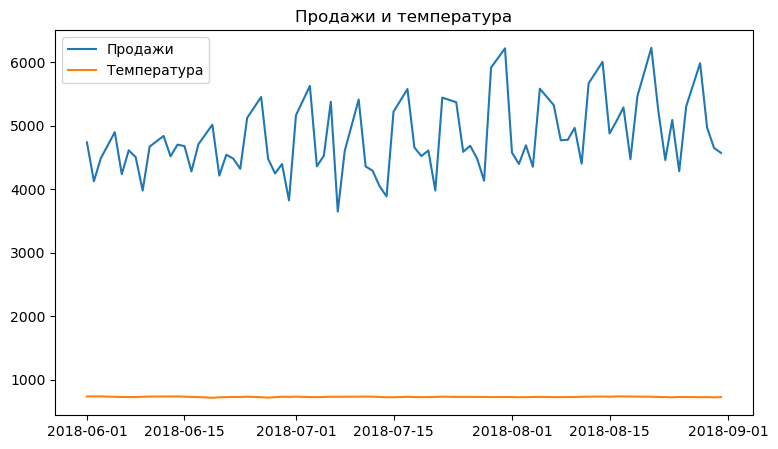

In [94]:
plt.figure(figsize=(9,5))

plt.plot(merged['Дата'], merged['Количество'], label='Продажи')
plt.plot(merged['Дата'], merged['T'], label='Температура')

plt.legend()
plt.title('Продажи и температура')
plt.show()

*На графике представлена динамика количества продаж и средней температуры воздуха по дням. Температура была агрегирована как среднее значение за день.*

*Видно, что продажи демонстрируют значительные колебания с выраженными пиками и спадами, в то время как температура изменяется более плавно.*

*Явной линейной зависимости между температурой и объемом продаж не наблюдается, однако в отдельные периоды можно заметить совпадение изменений этих показателей. Это может свидетельствовать о слабой или косвенной зависимости спроса от погодных условий.*